In [ ]:
#!/usr/bin/env python
# coding: utf-8

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from IPython.display import display
from scipy.integrate import odeint

# ------------------------------------------------------------------------------
# MODELO DE EXPRESIÓN GÉNICA CON FORMACIÓN DE DÍMERO
# ------------------------------------------------------------------------------
#
# Suponemos dos genes: genX y genY. Cada uno expresa una proteína:
#   - Proteína X, producida a tasa k_expr_X, degradada a tasa k_deg_X
#   - Proteína Y, producida a tasa k_expr_Y, degradada a tasa k_deg_Y
#
# Además, X y Y pueden formar un dímero XY:
#   - Dimerización:  X + Y  -> XY   con tasa k_dim
#   - Disociación:   XY -> X + Y   con tasa k_dis
#   - Degradación de XY: a tasa k_deg_XY
#
# El sistema de ecuaciones diferenciales es:
#
#   dX/dt  = k_expr_X - k_deg_X*X - k_dim*X*Y + k_dis*XY
#   dY/dt  = k_expr_Y - k_deg_Y*Y - k_dim*X*Y + k_dis*XY
#   dXY/dt = k_dim*X*Y - k_dis*XY - k_deg_XY*XY
#
# Con estos sliders podrás modificar las tasas y observar
# cómo varían las concentraciones en función del tiempo.
# ------------------------------------------------------------------------------


def sistema(U, t, k_expr_X, k_deg_X, k_expr_Y, k_deg_Y, k_dim, k_dis, k_deg_XY):
    """
    U        = [X, Y, XY] (concentraciones de proteínas y dímero)
    t        = tiempo
    k_expr_X = tasa de expresión de la proteína X
    k_deg_X  = tasa de degradación de la proteína X
    k_expr_Y = tasa de expresión de la proteína Y
    k_deg_Y  = tasa de degradación de la proteína Y
    k_dim    = tasa de dimerización (X + Y -> XY)
    k_dis    = tasa de disociación (XY -> X + Y)
    k_deg_XY = tasa de degradación del dímero XY
    """
    X, Y, XY = U
    
    # Ecuaciones diferenciales
    dXdt = k_expr_X - k_deg_X*X - k_dim*X*Y + k_dis*XY
    dYdt = k_expr_Y - k_deg_Y*Y - k_dim*X*Y + k_dis*XY
    dXYdt = k_dim*X*Y - k_dis*XY - k_deg_XY*XY
    
    return [dXdt, dYdt, dXYdt]


def resolver_sistema(k_expr_X, k_deg_X, k_expr_Y, k_deg_Y, k_dim, k_dis, k_deg_XY):
    """
    Resuelve el sistema de ecuaciones diferenciales
    para valores de parámetros dados y dibuja las soluciones
    en función del tiempo.
    """
    # Definimos el rango de tiempo para la simulación
    t = np.linspace(0, 50, 200)  # 50 unidades de tiempo, 200 puntos
    
    # Condiciones iniciales [X(0), Y(0), XY(0)]
    U0 = [0.0, 0.0, 0.0]  # Suponemos que inicialmente no hay proteínas
    
    # Resolvemos la EDO con odeint
    sol = odeint(
        sistema,
        U0,
        t,
        args=(k_expr_X, k_deg_X, k_expr_Y, k_deg_Y, k_dim, k_dis, k_deg_XY)
    )
    
    X_sol = sol[:, 0]
    Y_sol = sol[:, 1]
    XY_sol = sol[:, 2]
    
    # Graficamos los resultados
    plt.figure(figsize=(8, 5))
    plt.plot(t, X_sol, label='[X]', color='blue')
    plt.plot(t, Y_sol, label='[Y]', color='red')
    plt.plot(t, XY_sol, label='[XY]', color='green')
    plt.title('Expresión génica y formación de dímero')
    plt.xlabel('Tiempo')
    plt.ylabel('Concentración')
    plt.legend()
    plt.grid(True)
    
    # Ajustamos el eje Y para que cubra todo el rango de valores
    max_val = max(X_sol.max(), Y_sol.max(), XY_sol.max())
    plt.ylim(0, max_val*1.2 if max_val > 0 else 1)
    
    plt.show()


# ------------------------------------------------------------------------------
# CREACIÓN DE SLIDERS (INTERFAZ INTERACTIVA)
# ------------------------------------------------------------------------------
slider_k_expr_X = FloatSlider(value=1.0, min=0.0, max=5.0, step=0.1, description='k_expr_X')
slider_k_deg_X  = FloatSlider(value=0.1, min=0.0, max=1.0, step=0.01, description='k_deg_X')
slider_k_expr_Y = FloatSlider(value=1.0, min=0.0, max=5.0, step=0.1, description='k_expr_Y')
slider_k_deg_Y  = FloatSlider(value=0.1, min=0.0, max=1.0, step=0.01, description='k_deg_Y')
slider_k_dim    = FloatSlider(value=0.05, min=0.0, max=1.0, step=0.01, description='k_dim')
slider_k_dis    = FloatSlider(value=0.1, min=0.0, max=1.0, step=0.01, description='k_dis')
slider_k_deg_XY = FloatSlider(value=0.05, min=0.0, max=1.0, step=0.01, description='k_deg_XY')

# Interfaz interactiva
interactive_plot = interact(
    resolver_sistema,
    k_expr_X=slider_k_expr_X,
    k_deg_X=slider_k_deg_X,
    k_expr_Y=slider_k_expr_Y,
    k_deg_Y=slider_k_deg_Y,
    k_dim=slider_k_dim,
    k_dis=slider_k_dis,
    k_deg_XY=slider_k_deg_XY
)

display(interactive_plot)


interactive(children=(FloatSlider(value=1.0, description='k_expr_X', max=5.0), FloatSlider(value=0.1, descript…

<function __main__.resolver_sistema(k_expr_X, k_deg_X, k_expr_Y, k_deg_Y, k_dim, k_dis, k_deg_XY)>

**Formación de un cigoto (Z)**

A continuación un ejemplo de notebook en Python que modela la formación de un cigoto (Z) a partir de un gameto femenino (F) y un gameto masculino (M). Usamos la misma estructura de ecuaciones diferenciales que en el ejemplo anterior, pero reinterpretando las especies:

**𝐹:**  gameto femenino

**𝑀:** gameto masculino

**𝑍:**  cigoto formado al fusionarse 

Asumimos (de forma muy simplificada) que tanto 𝐹 como 𝑀 se producen a cierta tasa y pueden “degradarse” o eliminarse (morir, inactivarse, etc.), mientras que 𝑍 puede formarse por fusión de 𝐹 y 𝑀 y también puede “disociarse” o perderse (aunque biológicamente esto no es típico, se mantiene para la estructura matemática). El sistema de ecuaciones diferenciales es:

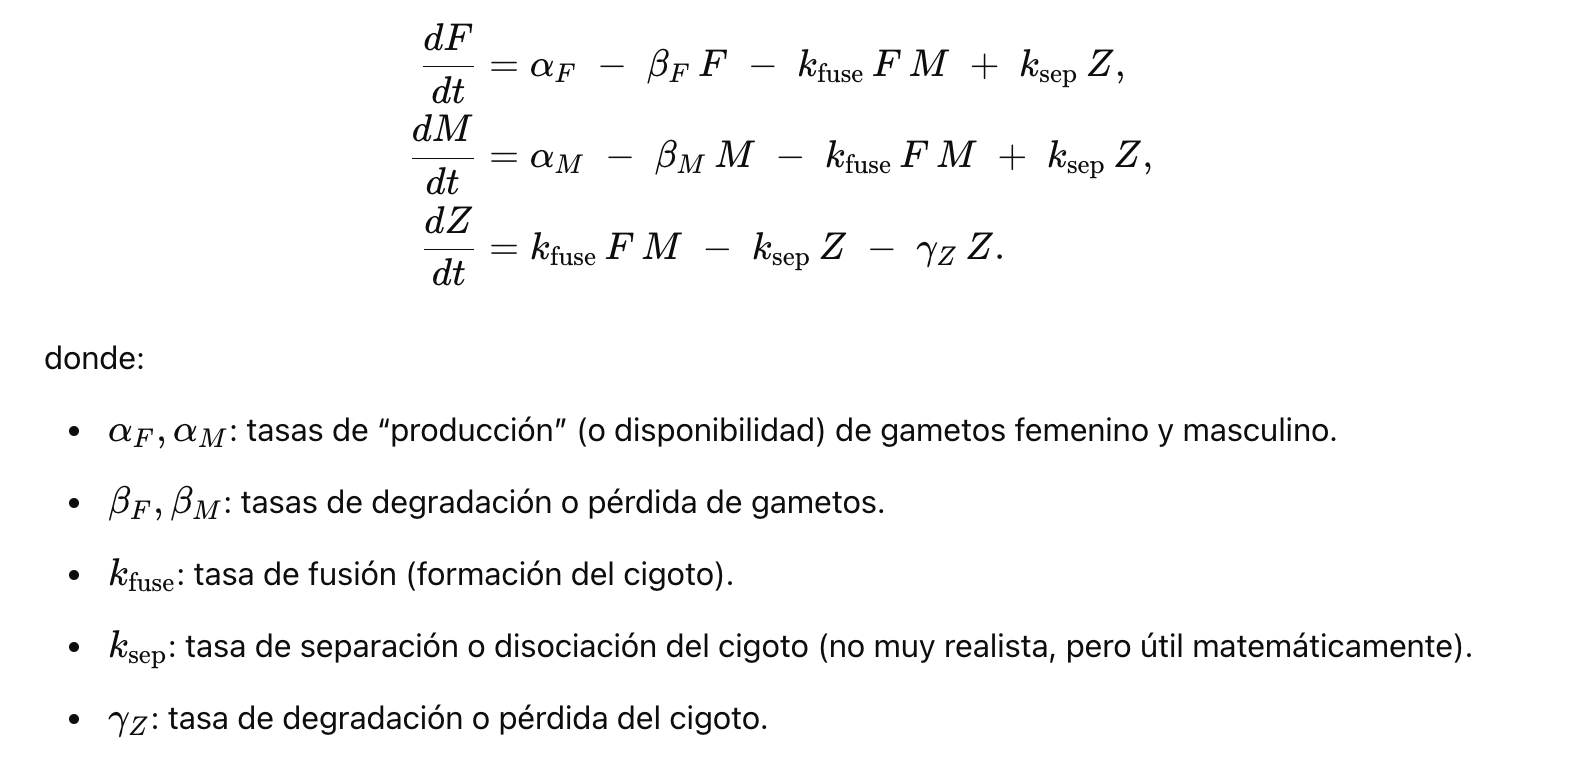


**Cómo usar este notebook**

Ajusta los sliders para ver cómo cambian las soluciones en el tiempo:

**αF, αM:** tasas de producción/disponibilidad de los gametos femenino y masculino.

**βF, βM:** tasas de degradación/pérdida de los gametos.

**k_fuse:** tasa de fusión entre los gametos para formar el cigoto.

**k_sep:** tasa de separación (un cigoto que se “rompe” de nuevo en F y M, simplificación puramente matemática).

**γZ:** tasa de degradación/pérdida del cigoto.

Se mostrará la evolución de 
**𝐹, 𝑀** y **𝑍** en el tiempo. Con esto podrás explorar de manera interactiva la dinámica de la formación de un cigoto bajo distintas hipótesis de producción, degradación y tasas de fusión.

Este script mofificado calcula e identifica el instante en el que la diferencia entre las concentraciones de los gametos es mínima (punto en el que se produce la fusión y da origen al cigoto). En la gráfica se dibuja una línea vertical en ese instante y se marcan con puntos en las curvas de F, M y Z, acompañados de una etiqueta que indica el "Punto de fusión".

Esto se interpreta como el instante en que la unión de los gametos es más efectiva, lo que favorece la formación del cigoto.

Marcado en la gráfica:

Se dibuja una línea vertical en el instante t_eq y se marcan con puntos sobre las curvas de F, M y Z, además de anotar el punto con la etiqueta "Fusión".

In [11]:
#!/usr/bin/env python
# coding: utf-8

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from IPython.display import display
from scipy.integrate import odeint

# ------------------------------------------------------------------------------
# DESCRIPCIÓN DEL SISTEMA:
# ------------------------------------------------------------------------------
# F: gameto femenino
# M: gameto masculino
# Z: cigoto
#
#   dF/dt = alpha_F - beta_F*F - k_fuse*F*M + k_sep*Z
#   dM/dt = alpha_M - beta_M*M - k_fuse*F*M + k_sep*Z
#   dZ/dt = k_fuse*F*M - k_sep*Z - gamma_Z*Z
#
# Parámetros:
#   alpha_F, alpha_M: tasas de producción o disponibilidad de F y M
#   beta_F, beta_M: tasas de degradación/perdida de F y M
#   k_fuse: tasa de fusión de F y M para formar Z
#   k_sep: tasa de separación de Z en F y M (simplificación no muy biológica)
#   gamma_Z: tasa de degradación/perdida de Z
# ------------------------------------------------------------------------------

def cigoto_system(U, t, alpha_F, beta_F, alpha_M, beta_M, k_fuse, k_sep, gamma_Z):
    """
    Define el sistema de EDOs para la formación de un cigoto Z
    a partir de gametos femenino (F) y masculino (M).
    """
    F, M, Z = U    
    dFdt = alpha_F - beta_F*F - k_fuse*F*M + k_sep*Z
    dMdt = alpha_M - beta_M*M - k_fuse*F*M + k_sep*Z
    dZdt = k_fuse*F*M - k_sep*Z - gamma_Z*Z    
    return [dFdt, dMdt, dZdt]

def resolver_cigoto(alpha_F, beta_F, alpha_M, beta_M, k_fuse, k_sep, gamma_Z):
    """
    Resuelve el sistema de ecuaciones diferenciales para los parámetros dados
    y grafica las soluciones en función del tiempo.
    
    Además, se identifica y marca el "Punto de fusión" (equilibrio) donde las curvas
    de los gametos convergen, indicando el instante en el que se forma el cigoto.
    """
    # Tiempo de simulación
    t = np.linspace(0, 50, 200)  # 50 unidades de tiempo, 200 puntos
    
    # Condiciones iniciales [F(0), M(0), Z(0)]
    U0 = [5.0, 5.0, 0.0]
    
    # Resolver la EDO
    sol = odeint(cigoto_system, U0, t, args=(alpha_F, beta_F, alpha_M, beta_M, k_fuse, k_sep, gamma_Z))
    F_sol = sol[:, 0]
    M_sol = sol[:, 1]
    Z_sol = sol[:, 2]
    
    # Cálculo del "Punto de fusión"
    # Se busca el instante en que la diferencia |F - M| es mínima
    idx_eq = np.argmin(np.abs(F_sol - M_sol))
    t_eq = t[idx_eq]
    F_eq = F_sol[idx_eq]
    M_eq = M_sol[idx_eq]
    Z_eq = Z_sol[idx_eq]
    
    # Graficar resultados
    plt.figure(figsize=(8, 5))
    plt.plot(t, F_sol, label='Gameto femenino (F)', color='blue')
    plt.plot(t, M_sol, label='Gameto masculino (M)', color='red')
    plt.plot(t, Z_sol, label='Cigoto (Z)', color='green')
    
    # Marcar el "Punto de fusión" con una línea vertical y puntos en cada curva
    plt.axvline(x=t_eq, color='gray', linestyle='--', label='Punto de fusión')
    plt.scatter(t_eq, F_eq, color='purple', s=80, zorder=6)
    plt.scatter(t_eq, M_eq, color='purple', s=80, zorder=6)
    plt.scatter(t_eq, Z_eq, color='orange', s=80, zorder=6)
    plt.text(t_eq, F_eq, " Fusión", ha='right', va='bottom', color='purple')
    
    plt.title('Dinámica de la formación de un cigoto')
    plt.xlabel('Tiempo')
    plt.ylabel('Cantidad (concentración)')
    plt.legend()
    plt.ylim(0, max(F_sol.max(), M_sol.max(), Z_sol.max())*1.2)
    plt.grid(True)
    plt.show()

# ------------------------------------------------------------------------------
# CREACIÓN DE SLIDERS (INTERFAZ INTERACTIVA)
# ------------------------------------------------------------------------------
slider_alpha_F = FloatSlider(value=1.0, min=0.0, max=5.0, step=0.1, description='αF')
slider_beta_F  = FloatSlider(value=0.1, min=0.0, max=1.0, step=0.01, description='βF')
slider_alpha_M = FloatSlider(value=1.0, min=0.0, max=5.0, step=0.1, description='αM')
slider_beta_M  = FloatSlider(value=0.1, min=0.0, max=1.0, step=0.01, description='βM')
slider_k_fuse  = FloatSlider(value=0.05, min=0.0, max=1.0, step=0.01, description='k_fuse')
slider_k_sep   = FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01, description='k_sep')
slider_gamma_Z = FloatSlider(value=0.05, min=0.0, max=1.0, step=0.01, description='γZ')

interactive_plot = interact(
    resolver_cigoto,
    alpha_F=slider_alpha_F,
    beta_F=slider_beta_F,
    alpha_M=slider_alpha_M,
    beta_M=slider_beta_M,
    k_fuse=slider_k_fuse,
    k_sep=slider_k_sep,
    gamma_Z=slider_gamma_Z
)

display(interactive_plot)


interactive(children=(FloatSlider(value=1.0, description='αF', max=5.0), FloatSlider(value=0.1, description='β…

<function __main__.resolver_cigoto(alpha_F, beta_F, alpha_M, beta_M, k_fuse, k_sep, gamma_Z)>